In [1]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
import xarray as xr

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
slice_str = "2024-07-16T00:00:00, 2024-07-16T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))

In [3]:
# Load the entire datasets dictionary
with open('era5_datasets_sens_1min.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Now you can access your original variables
rain_rate = loaded_data['rain_rate']
time_min = loaded_data['time']
X_min = loaded_data['state']
R_min = loaded_data['R']
Z_t_min = loaded_data['Z_t']
Z_t_min = loaded_data['Z_t_new']
metadata_min = loaded_data['metadata']

In [37]:
# Load the entire datasets dictionary
with open('era5_datasets_sens_1hr.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Now you can access your original variables
rain_rate_hr = loaded_data['rain_rate']
time_hr = loaded_data['time']
X_hr = loaded_data['state']
R_hr = loaded_data['R']
Z_t_hr = loaded_data['Z_t']
Z_t_hr = loaded_data['Z_t_new']
metadata_hr = loaded_data['metadata']

In [38]:
# Load the entire datasets dictionary
with open('era5_datasets_sens_series.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Now you can access your original variables
rain_rate_series = loaded_data['rain_rate']
time_series = loaded_data['time']
X_series = loaded_data['state']
R_series = loaded_data['R']
Z_t_series = loaded_data['Z_t']
Z_t_series = loaded_data['Z_t_new']
metadata_series = loaded_data['metadata']

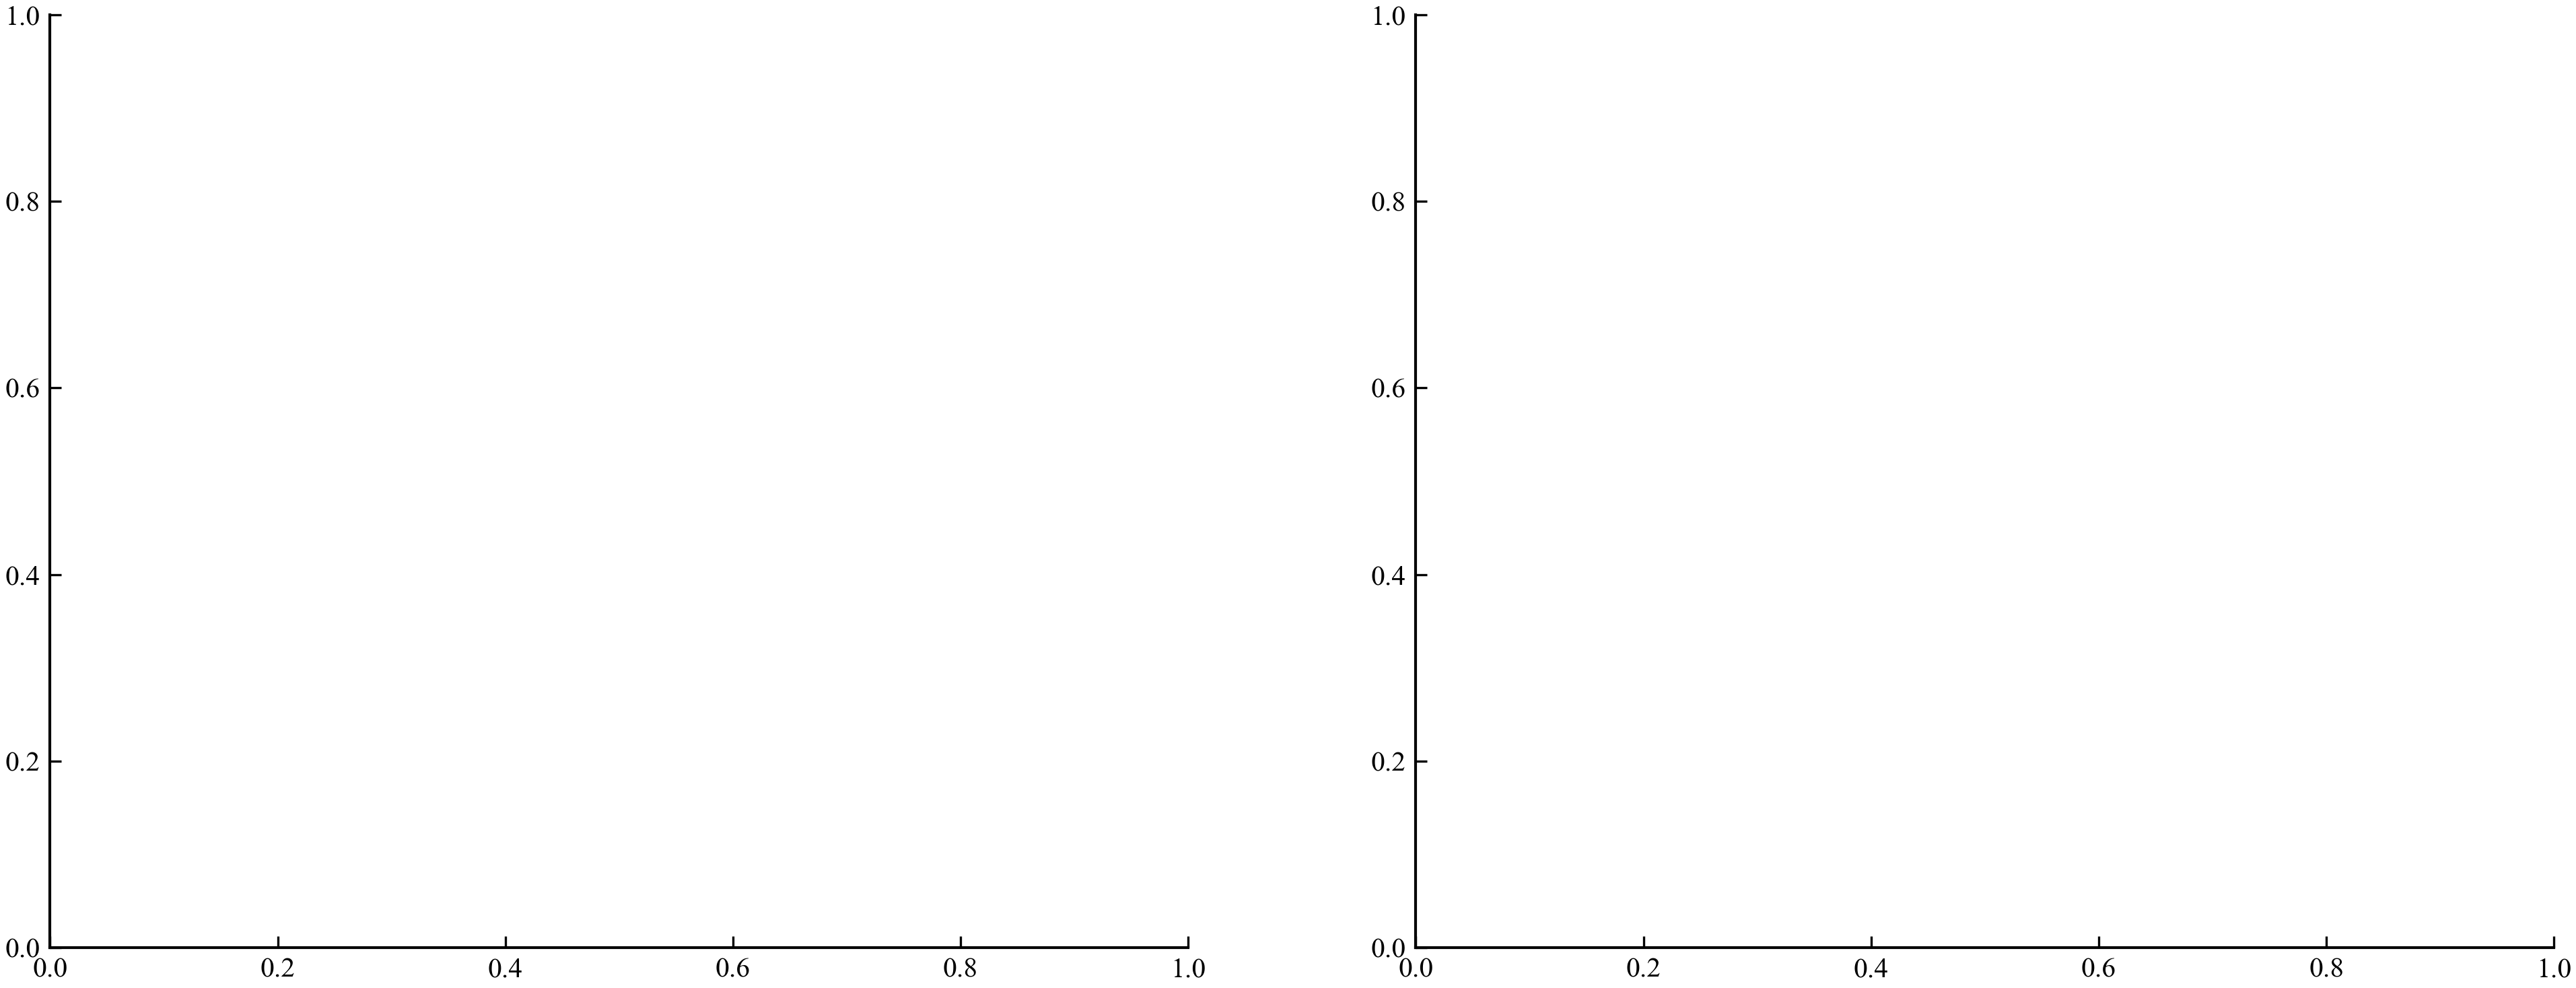

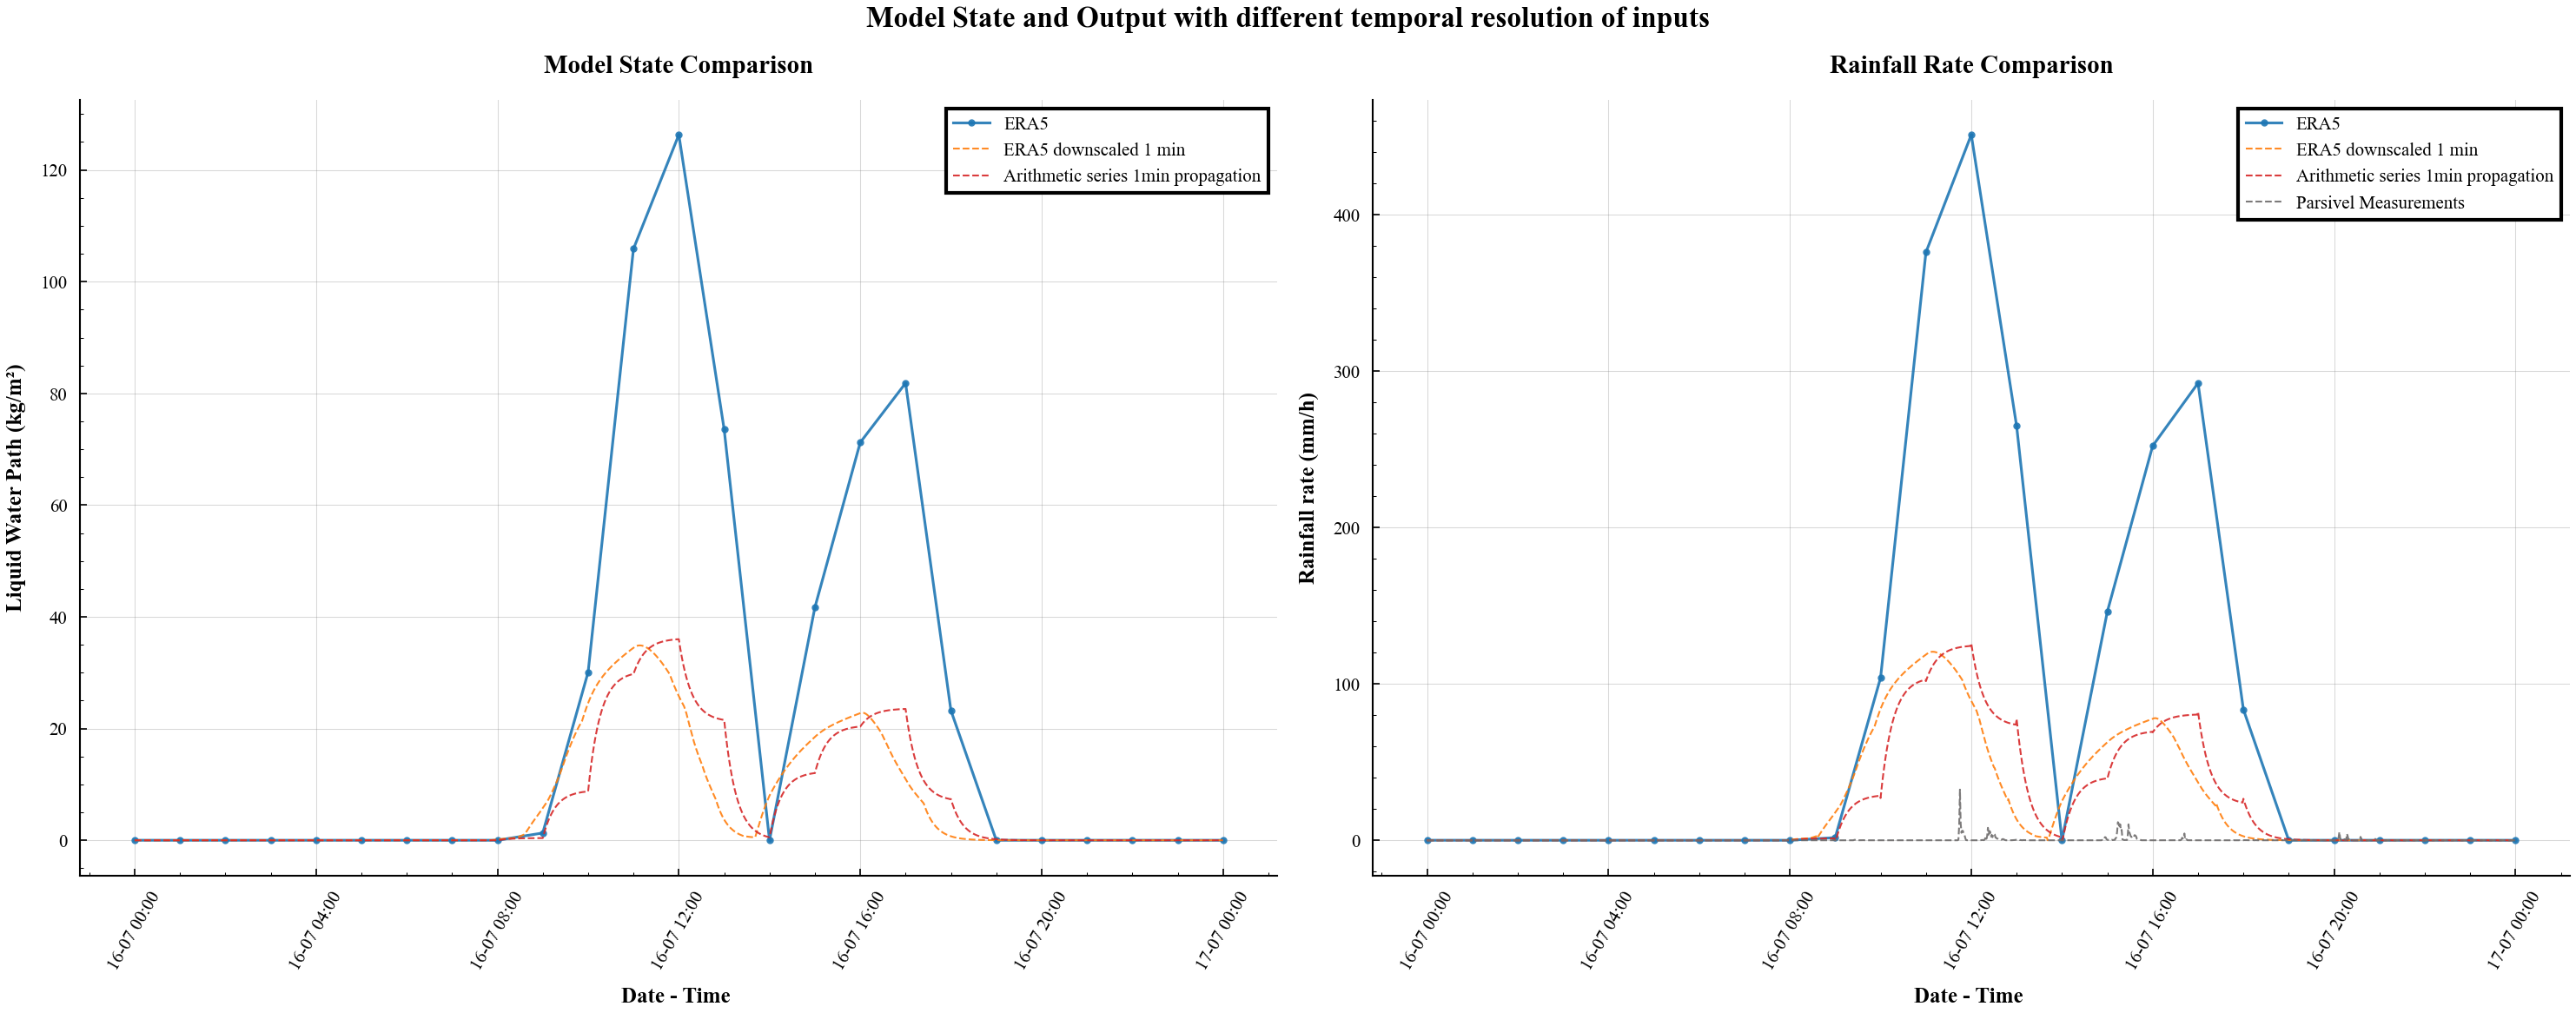

In [43]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure with two horizontal subplots - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20 * SCALE_FACTOR, 8 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors2 = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': "#6e6c6c00",      # Red - spline linear
    'cubic': '#ff7f0e',        # Orange - cubic
    'no_entrainment': '#d62728'  # Red  
}


# ==================== SUBPLOT 1: Rainfall Rate ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line1_parsivel = ax2.plot(time_hr, R_hr*3600, 
                         color=colors2['era5_10'], 
                         label='ERA5',
                         linewidth=1.5 * SCALE_FACTOR,
                                                                        marker='o',
                      markersize=2 * SCALE_FACTOR,
                         alpha=0.9)

line1_model = ax2.plot(time_min, R_min*3600, 
                      color=colors2['cubic'], 
                      linestyle='--', 
                      label='ERA5 downscaled 1 min',
                      linewidth=1.0 * SCALE_FACTOR,
                      alpha=0.9)

line4_model = ax2.plot(time_min[:-1], R_series*3600, 
                      color=colors2['no_entrainment'], 
                      linestyle='--', 
                      label='Arithmetic series 1min propagation',
                      linewidth=1.0 * SCALE_FACTOR,
                      alpha=0.9)
line_3 = ax2.plot(rain_rate.time, rain_rate,
                        color=colors2['slinear'], 
                      linestyle='--', 
                      label='Parsivel Measurements',
                      linewidth=1.0 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Date - Time ', fontweight='bold')
ax2.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax2.set_title('Rainfall Rate Comparison', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=1 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting
ax2.ticklabel_format(style='plain', axis='y')
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# ==================== SUBPLOT 2: Liquid Water Path (LWP) ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line2_parsivel = ax1.plot(time_hr, X_hr, 
                         color=colors2['era5_10'], 
                         label='ERA5',
                         linewidth=1.5 * SCALE_FACTOR,
                                               marker='o',
                      markersize=2 * SCALE_FACTOR,
                         alpha=0.9)

line2_model = ax1.plot(time_min, X_min, 
                      color=colors2['cubic'], 
                      linestyle='--', 
                      label='ERA5 downscaled 1 min',
                      linewidth=1.0 * SCALE_FACTOR,
                      alpha=0.9)
line4_model = ax1.plot(time_min[:-1],X_series.reshape(-1), 
                      color=colors2['no_entrainment'], 
                      linestyle='--', 
                      label='Arithmetic series 1min propagation',
                      linewidth=1.0 * SCALE_FACTOR,

                      alpha=0.9)
"""
line_3 = ax1.plot(rain_rate.time, rain_rate,
                        color=colors2['slinear'], 
                      linestyle='--', 
                      label='Parsivel Measurements',
                      linewidth=2.0 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)
"""
# Scientific axis labels with units
ax1.set_xlabel('Date - Time ', fontweight='bold')
ax1.set_ylabel('Liquid Water Path (kg/m²)', fontweight='bold')
ax1.set_title('Model State Comparison', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=1 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting
ax1.ticklabel_format(style='plain', axis='y')
ax1.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# ==================== SHARED TIME AXIS FORMATTING ====================
# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 2  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 4  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'
    rotation = 45

# Apply time formatting to both subplots
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Overall figure title
fig.suptitle('Model State and Output with different temporal resolution of inputs',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=0.98)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, top=0.85)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'era5_validation_rainfall_lwp_comparison.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

In [44]:
plt.plot(time_min, X_min)
plt.plot(time_hr, X_hr)

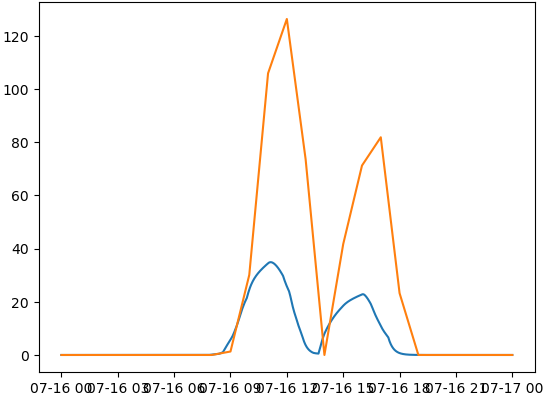

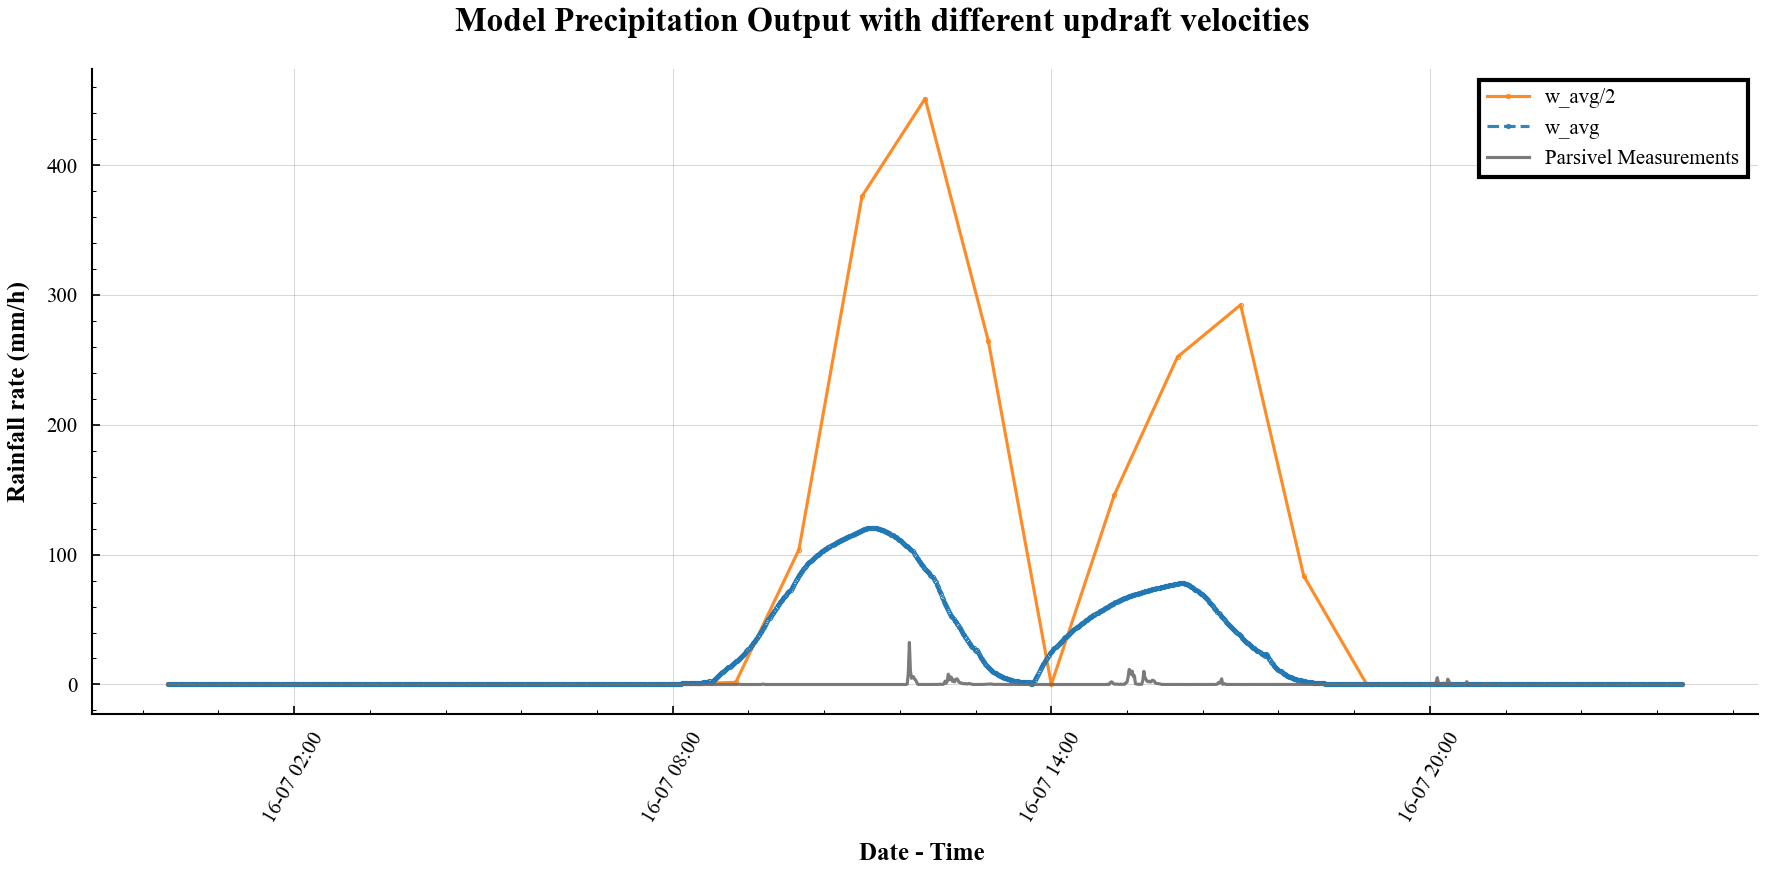

In [45]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure with two horizontal subplots - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors2 = {
    'cubic': '#1f77b4',      # Blue - 10-level
    'slinear': "#6e6c6c00",      # Red - spline linear
    'era5_10': '#ff7f0e',        # Orange - cubic
}


# ==================== SUBPLOT 1: Rainfall Rate ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line1_parsivel = ax.plot(time_hr, R_hr*3600, 
                         color=colors2['era5_10'], 
                         label='w_avg/2',
                         linewidth=1.5 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)

line1_model = ax.plot(time_min, R_min*3600, 
                      color=colors2['cubic'], 
                      linestyle='--', 
                      label='w_avg',
                      linewidth=1.5 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)
line_3 = ax.plot(rain_rate.time, rain_rate,
                        color=colors2['slinear'], 
                      label='Parsivel Measurements',
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax.set_xlabel('Date - Time ', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
#ax.set_title('Rainfall Rate Comparison', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=1 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# ==================== SUBPLOT 2: Liquid Water Path (LWP) ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR


# ==================== SHARED TIME AXIS FORMATTING ====================
# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 2  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 6  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'
    rotation = 45

# Apply time formatting to both subplots
for ax in [ax]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Overall figure title
fig.suptitle('Model Precipitation Output with different updraft velocities',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=0.98)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, top=0.85)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [46]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # Adjust as needed

# Scientific publication-quality styling
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',
})

# Create figure with two horizontal subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Get surface level
surface = data_era_30.level.values[0]

# ==================== SUBPLOT 1: Different ERA5 Datasets ====================
# Scientific color palette for different datasets
colors1 = {
    'era5': '#1f77b4',      # Blue
    'era5_30': '#d62728',   # Red  
    'era5_10': '#ff7f0e' ,   # Orange
   'measurements':'#6a4c93'
}

# Data for first subplot
temp_era = data_era.temperature.sel(level=surface)
temp_era_1_min = data_era_1_min.temperature.sel(level=surface)  
temp_era_10 = data_era_10_min.temperature.sel(level=surface)

# Plot with scientific styling
line1_1 = temp_era.plot(ax=ax1, 
                       color=colors1['era5'], 
                       label='ERA5 Standard',
                       linestyle='-', 
                       linewidth=2.0 * SCALE_FACTOR,
                       alpha=0.9,
                       add_legend=False)



line1_3 = temp_era_10.plot(ax=ax1,
                          color=colors1['era5_10'], 
                          label='ERA5 downscaled 10 min',
                          linestyle=':', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)
line1_2 = temp_era_1_min.plot(ax=ax1,
                          color=colors1['era5_30'], 
                          label='ERA5 downscaled 1 min',
                          linestyle='--', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

line_meteo = measurements_used.TA002.plot(ax=ax1,
                          color=colors1['measurements'], 
                          label='CESAR Measurements',
                          linestyle='-.', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

# Styling for subplot 1
ax1.set_ylabel('Temperature (K)', fontweight='bold')
ax1.set_xlabel('Date - Time', fontweight='bold')
ax1.set_title(f'ERA5 Dataset Comparison\nSurface Level: {surface:.0f} hPa',
              fontweight='bold', pad=20 * SCALE_FACTOR)

ax1.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax1.set_axisbelow(True)
ax1.minorticks_on()

legend1 = ax1.legend(loc='best',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

ax1.tick_params(which='major', length=6 * SCALE_FACTOR, width=1.2 * SCALE_FACTOR)
ax1.tick_params(which='minor', length=3 * SCALE_FACTOR, width=0.8 * SCALE_FACTOR)

# ==================== SUBPLOT 2: Interpolation Methods ====================
# Scientific color palette for interpolation methods
colors2 = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': '#d62728',      # Red - spline linear
    'cubic': '#ff7f0e', 
    'quadratic': '#4caf50'       # Orange - cubic
}

# Data for second subplot
temp_era_10_interp = data_era_10.temperature.sel(level=surface)
temp_era_quadratic = data_era_quadratic.temperature.sel(level=surface)
temp_era_slinear = data_era_slinear.temperature.sel(level=surface)
temp_era_cubic = data_era_cubic.temperature.sel(level=surface)

# Plot with scientific styling - comparing interpolation methods
line2_1 = temp_era_10_interp.plot(ax=ax2, 
                                 color=colors2['era5_10'], 
                                 label='Linear Interpolation',
                                 linestyle='-', 
                                 linewidth=2.0 * SCALE_FACTOR,
                                 alpha=0.9,
                                 add_legend=False)
line_3 = temp_era_quadratic.plot(ax=ax2, 
                                 color=colors2['quadratic'], 
                                 label='Quadratic Interpolation',
                                 linestyle='-.', 
                                 linewidth=2.0 * SCALE_FACTOR,
                                 alpha=0.9,
                                 add_legend=False)

line2_2 = temp_era_slinear.plot(ax=ax2,
                               color=colors2['slinear'], 
                               label='Spline Linear Interpolation',
                               linestyle='--', 
                               linewidth=2.0 * SCALE_FACTOR,
                               alpha=0.9,
                               add_legend=False)

line2_3 = temp_era_cubic.plot(ax=ax2,
                             color=colors2['cubic'], 
                             label='Cubic Interpolation',
                             linestyle=':', 
                             linewidth=2.0 * SCALE_FACTOR,
                             alpha=0.9,
                             add_legend=False)
line_meteo = measurements_used.TA002.plot(ax=ax2,
                          color=colors1['measurements'], 
                          label='CESAR Measurements',
                          linestyle='-.', 
                          linewidth=2.0 * SCALE_FACTOR,
                          alpha=0.9,
                          add_legend=False)

# Styling for subplot 2
ax2.set_ylabel('Temperature (K)', fontweight='bold')
ax2.set_xlabel('Date - Time', fontweight='bold')
ax2.set_title(f'Interpolation Method Comparison (1 minute) \nSurface Level: {surface:.0f} hPa',
              fontweight='bold', pad=20 * SCALE_FACTOR)

ax2.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax2.set_axisbelow(True)
ax2.minorticks_on()

legend2 = ax2.legend(loc='best',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

ax2.tick_params(which='major', length=6 * SCALE_FACTOR, width=1.2 * SCALE_FACTOR)
ax2.tick_params(which='minor', length=3 * SCALE_FACTOR, width=0.8 * SCALE_FACTOR)

# ==================== SHARED FORMATTING - HIGH TEMPORAL RESOLUTION ====================
# Format x-axis for both subplots with increased temporal resolution
for ax in [ax1, ax2]:
    try:
        # Get the first data variable to check if it's time-based
        first_data = list(ax.get_lines())[0].get_xdata()
        if hasattr(first_data, 'dtype') and 'datetime' in str(first_data.dtype):
            # High temporal resolution formatting
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Major ticks every 6 hours
            
            # Minor ticks for even finer resolution
            ax.xaxis.set_minor_locator(mdates.HourLocator(interval=1))  # Minor ticks every hour
            
            # Rotate labels for better readability with more frequent ticks
            plt.setp(ax.xaxis.get_majorticklabels(), 
                    rotation=45, 
                    ha='right', 
                    fontsize=9*SCALE_FACTOR)
        else:
            # For non-datetime data, increase tick frequency
            ax.locator_params(axis='x', nbins=12)  # More x-axis ticks
    except:
        # Fallback: increase number of ticks
        ax.locator_params(axis='x', nbins=15)

# Overall figure title
fig.suptitle('Temperature Data Analysis: Dataset and Interpolation Comparison',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=0.98)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, top=0.85)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults after plotting
plt.rcParams.update(plt.rcParamsDefault)

NameError: name 'data_era_30' is not defined

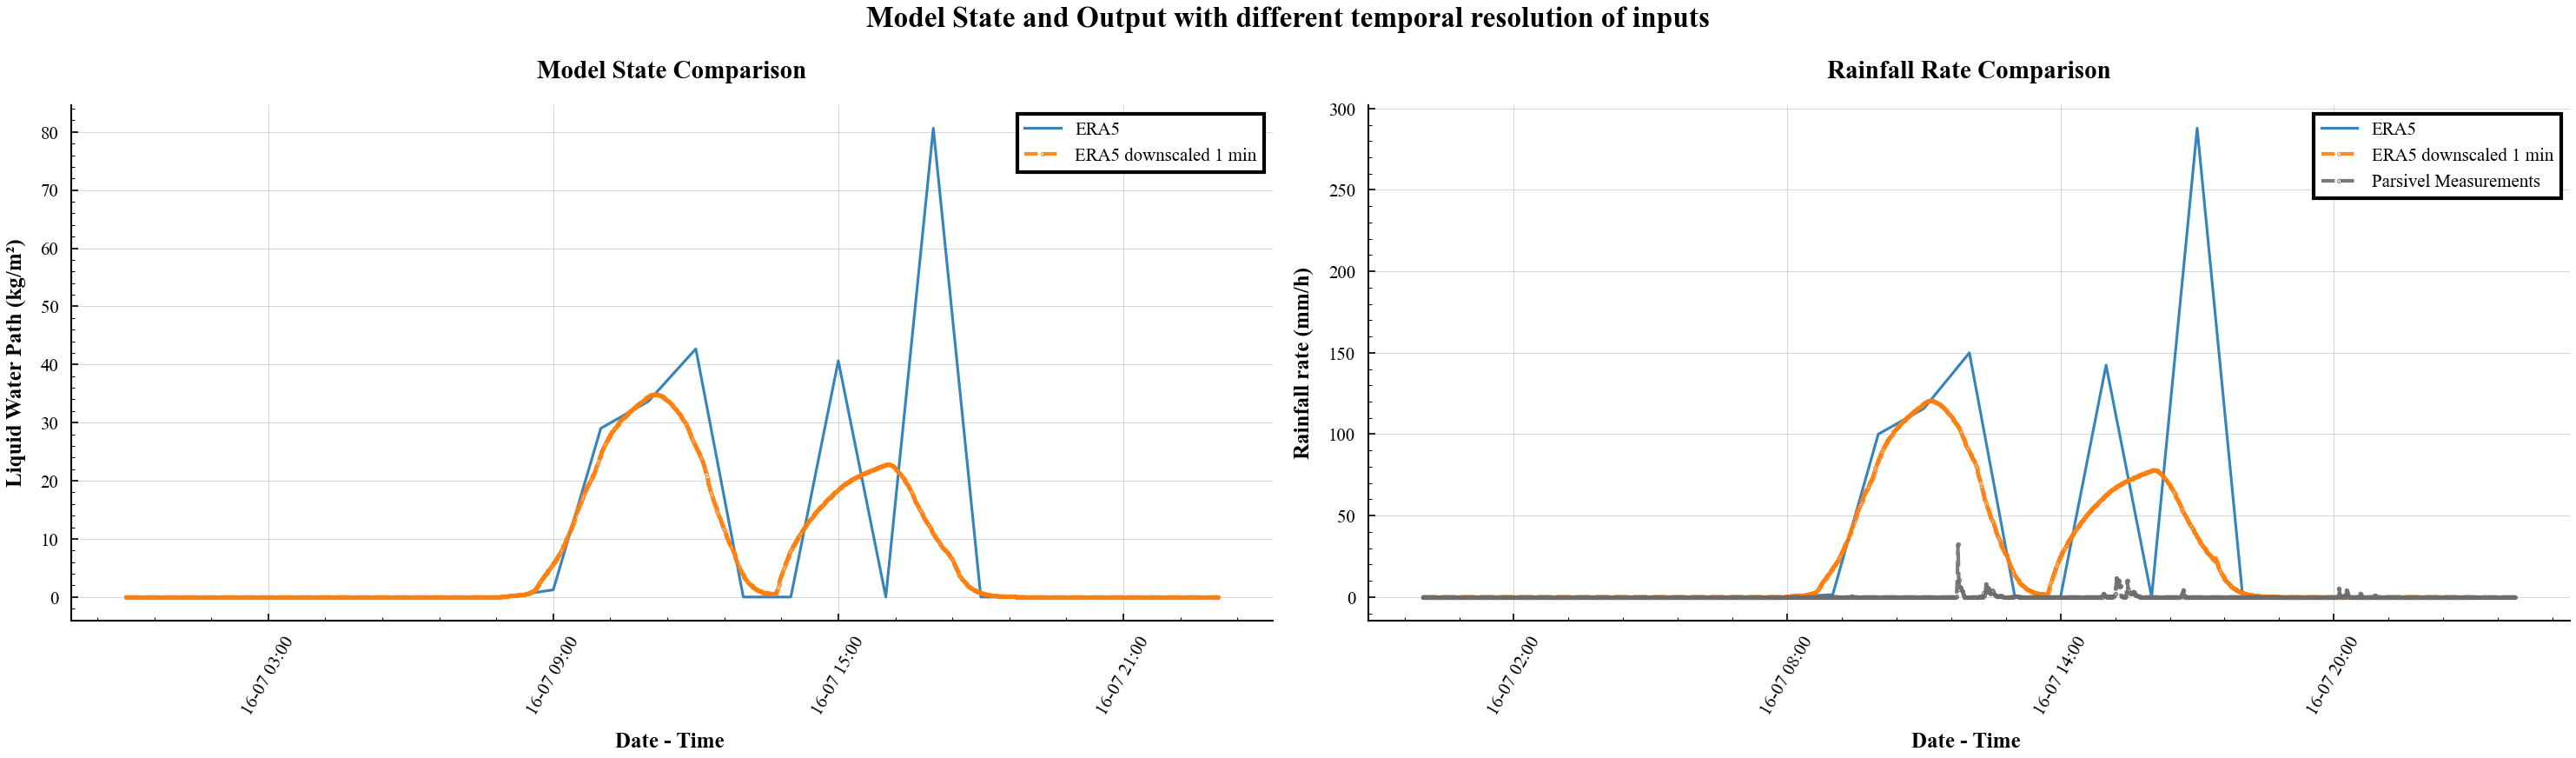

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter

plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure with two horizontal subplots - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors2 = {
    'era5_10': '#1f77b4',      # Blue - 10-level
    'slinear': "#6e6c6c00",      # Red - spline linear
    'cubic': '#ff7f0e',        # Orange - cubic
}


# ==================== SUBPLOT 1: Rainfall Rate ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line1_parsivel = ax2.plot(time_hr, R_hr*3600, 
                         color=colors2['era5_10'], 
                         label='ERA5',
                         linewidth=1.5 * SCALE_FACTOR,
                         alpha=0.9)

line1_model = ax2.plot(time_min, R_min*3600, 
                      color=colors2['cubic'], 
                      linestyle='--', 
                      label='ERA5 downscaled 1 min',
                      linewidth=2.0 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)
line_3 = ax2.plot(rain_rate.time, rain_rate,
                        color=colors2['slinear'], 
                      linestyle='--', 
                      label='Parsivel Measurements',
                      linewidth=2.0 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Date - Time ', fontweight='bold')
ax2.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax2.set_title('Rainfall Rate Comparison', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=1 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting
ax2.ticklabel_format(style='plain', axis='y')
ax2.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# ==================== SUBPLOT 2: Liquid Water Path (LWP) ====================
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line2_parsivel = ax1.plot(time_hr, X_hr, 
                         color=colors2['era5_10'], 
                         label='ERA5',
                         linewidth=1.5 * SCALE_FACTOR,
                         alpha=0.9)

line2_model = ax1.plot(time_min, X_min, 
                      color=colors2['cubic'], 
                      linestyle='--', 
                      label='ERA5 downscaled 1 min',
                      linewidth=2.0 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)
"""
line_3 = ax1.plot(rain_rate.time, rain_rate,
                        color=colors2['slinear'], 
                      linestyle='--', 
                      label='Parsivel Measurements',
                      linewidth=2.0 * SCALE_FACTOR,
                      marker='o',
                      markersize=0.5 * SCALE_FACTOR,
                      alpha=0.9)
"""
# Scientific axis labels with units
ax1.set_xlabel('Date - Time ', fontweight='bold')
ax1.set_ylabel('Liquid Water Path (kg/m²)', fontweight='bold')
ax1.set_title('Model State Comparison', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=1 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting
ax1.ticklabel_format(style='plain', axis='y')
ax1.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# ==================== SHARED TIME AXIS FORMATTING ====================
# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 2  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 6  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'
    rotation = 45

# Apply time formatting to both subplots
for ax in [ax1, ax2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Overall figure title
fig.suptitle('Model State and Output with different temporal resolution of inputs',
             fontweight='bold', 
             fontsize=16*SCALE_FACTOR, 
             y=0.98)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, top=0.85)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'era5_validation_rainfall_lwp_comparison.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

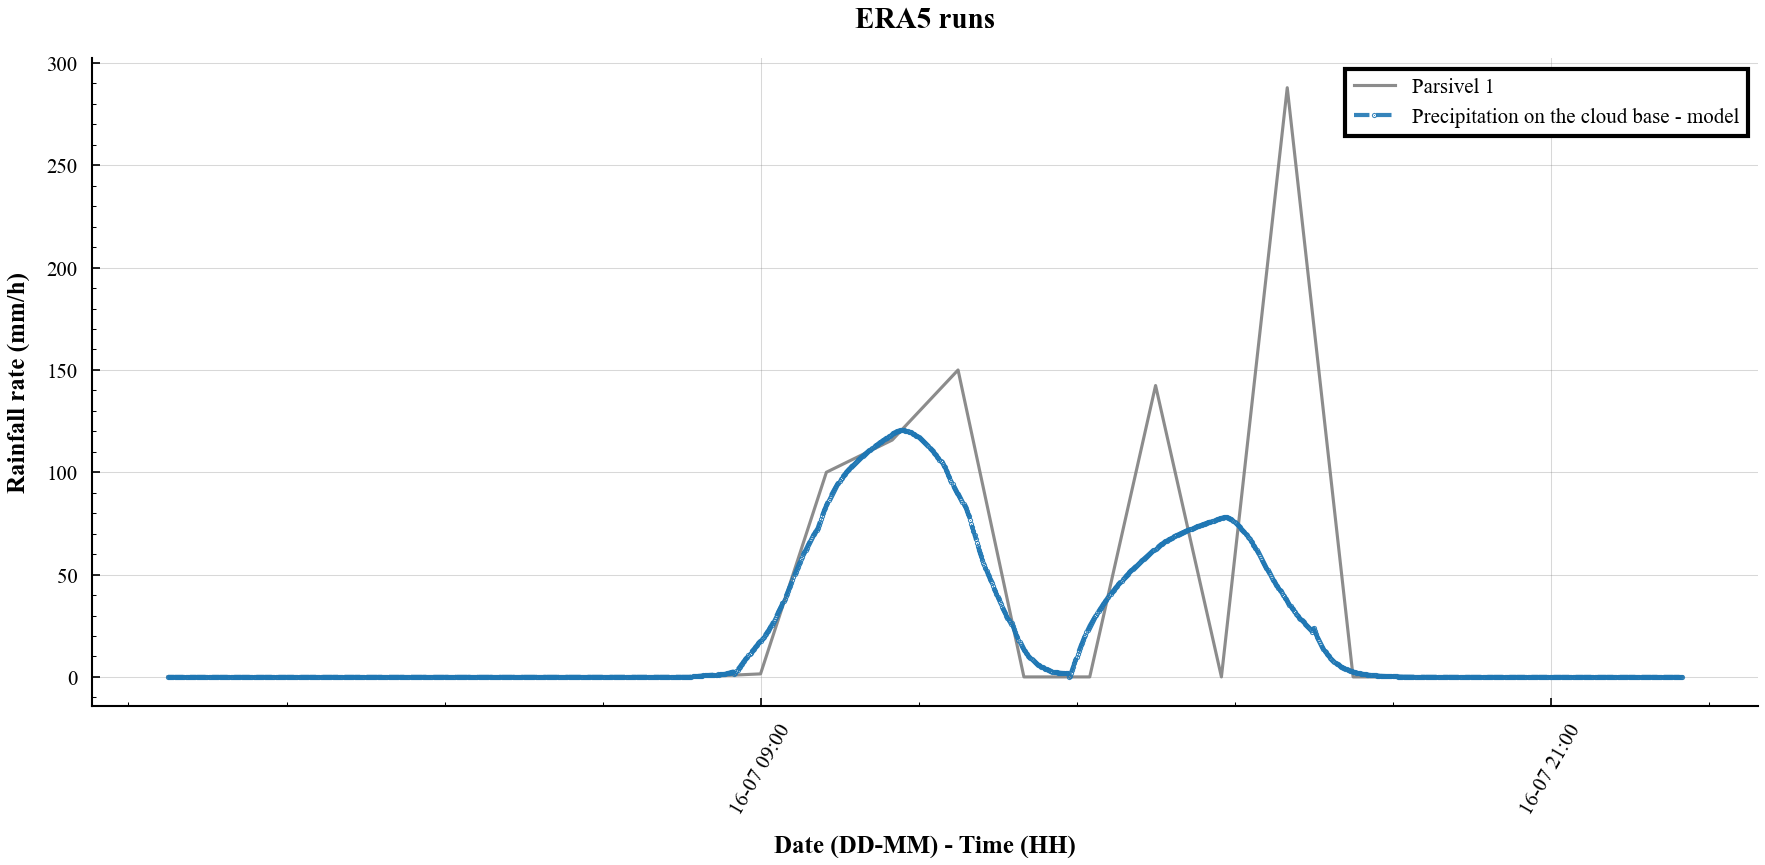

In [ ]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model': '#1f77b4',       # Blue
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(time_hr, R_hr*3600, 
                       color=colors['parsivel'], 
                       label='Parsivel 1',
                       linewidth=1.5 * SCALE_FACTOR,
                       alpha=0.9)

line_model = ax.plot(time_min, R_min*3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Precipitation on the cloud base - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    marker='o',
                    markersize=0.5 * SCALE_FACTOR,
                    alpha=0.9)

#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('ERA5 runs', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=1 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'rainfall_rate_era5_entrainment.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')
#             format='pdf', dpi=600, bbox_inches='tight')

In [ ]:
from scipy import stats
print(stats.pearsonr(R_era*3600, hourly_avg),stats.pearsonr(R_mwr_hourly, hourly_avg))

PearsonRResult(statistic=0.4727832793783895, pvalue=0.0006905968245727438) PearsonRResult(statistic=0.1425452347405169, pvalue=0.3337954234528494)
